In [1]:
%%capture
! pip install laspy

In [2]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

# File system operations
import os

# Return type hints
from typing import Tuple, List, Union


from scipy.spatial import KDTree

In [3]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = las.classification == filter_class
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None

In [143]:
def normalize_points(points) -> np.ndarray:
    """
    Normalize points to the range [0, 1] based on their minimum and maximum coordinates.
    """
    min_coords = points.min(axis=0, keepdims=True)
    max_coords = points.max(axis=0, keepdims=True)
    return (points - min_coords) / (max_coords - min_coords)

In [144]:
def plot_normalized_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red and normalized coordinates.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # Normalize points to start from (0, 0, 0)
        points = normalize_points(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Normalized)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.view_init(elev=30, azim=45)
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")

In [145]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

In [146]:
def plot_z_distribution(points: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given points on a specific subplot, with outlier boundaries.
    """
    z_values = points[:, 2]

    lower_bound, upper_bound = calculate_iqr_outliers(z_values)

    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")

    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")

    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

In [147]:
def preprocess_data(points: np.ndarray) -> np.ndarray:
    """
    Preprocess LiDAR points by normalizing them and removing outliers based on the IQR method.
    """
    normalized_points = normalize_points(points)
    z_values = normalized_points[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)

    filtered_points = normalized_points[mask]

    return filtered_points

In [148]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)

    train_data = data[:split_idx]
    test_data = data[split_idx:]

    return train_data, test_data

In [149]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""

    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"

    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False
        # This may lead to not every point being marked as seed in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [150]:
plot_las_files = [f"data/als/plot_{i:02d}.las" for i in range(1, 11)]


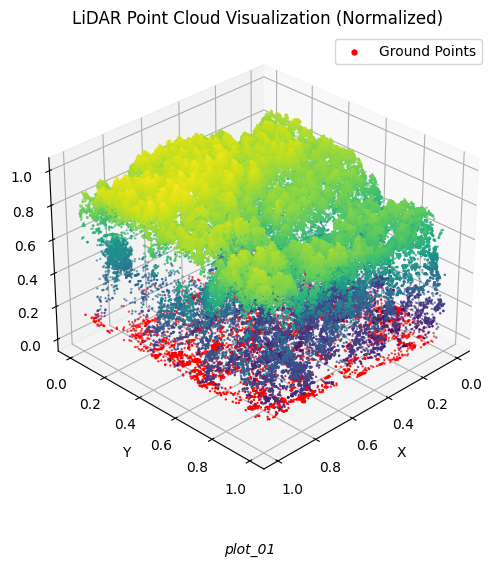

In [151]:
plot_normalized_lidar(plot_las_files[0])


Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


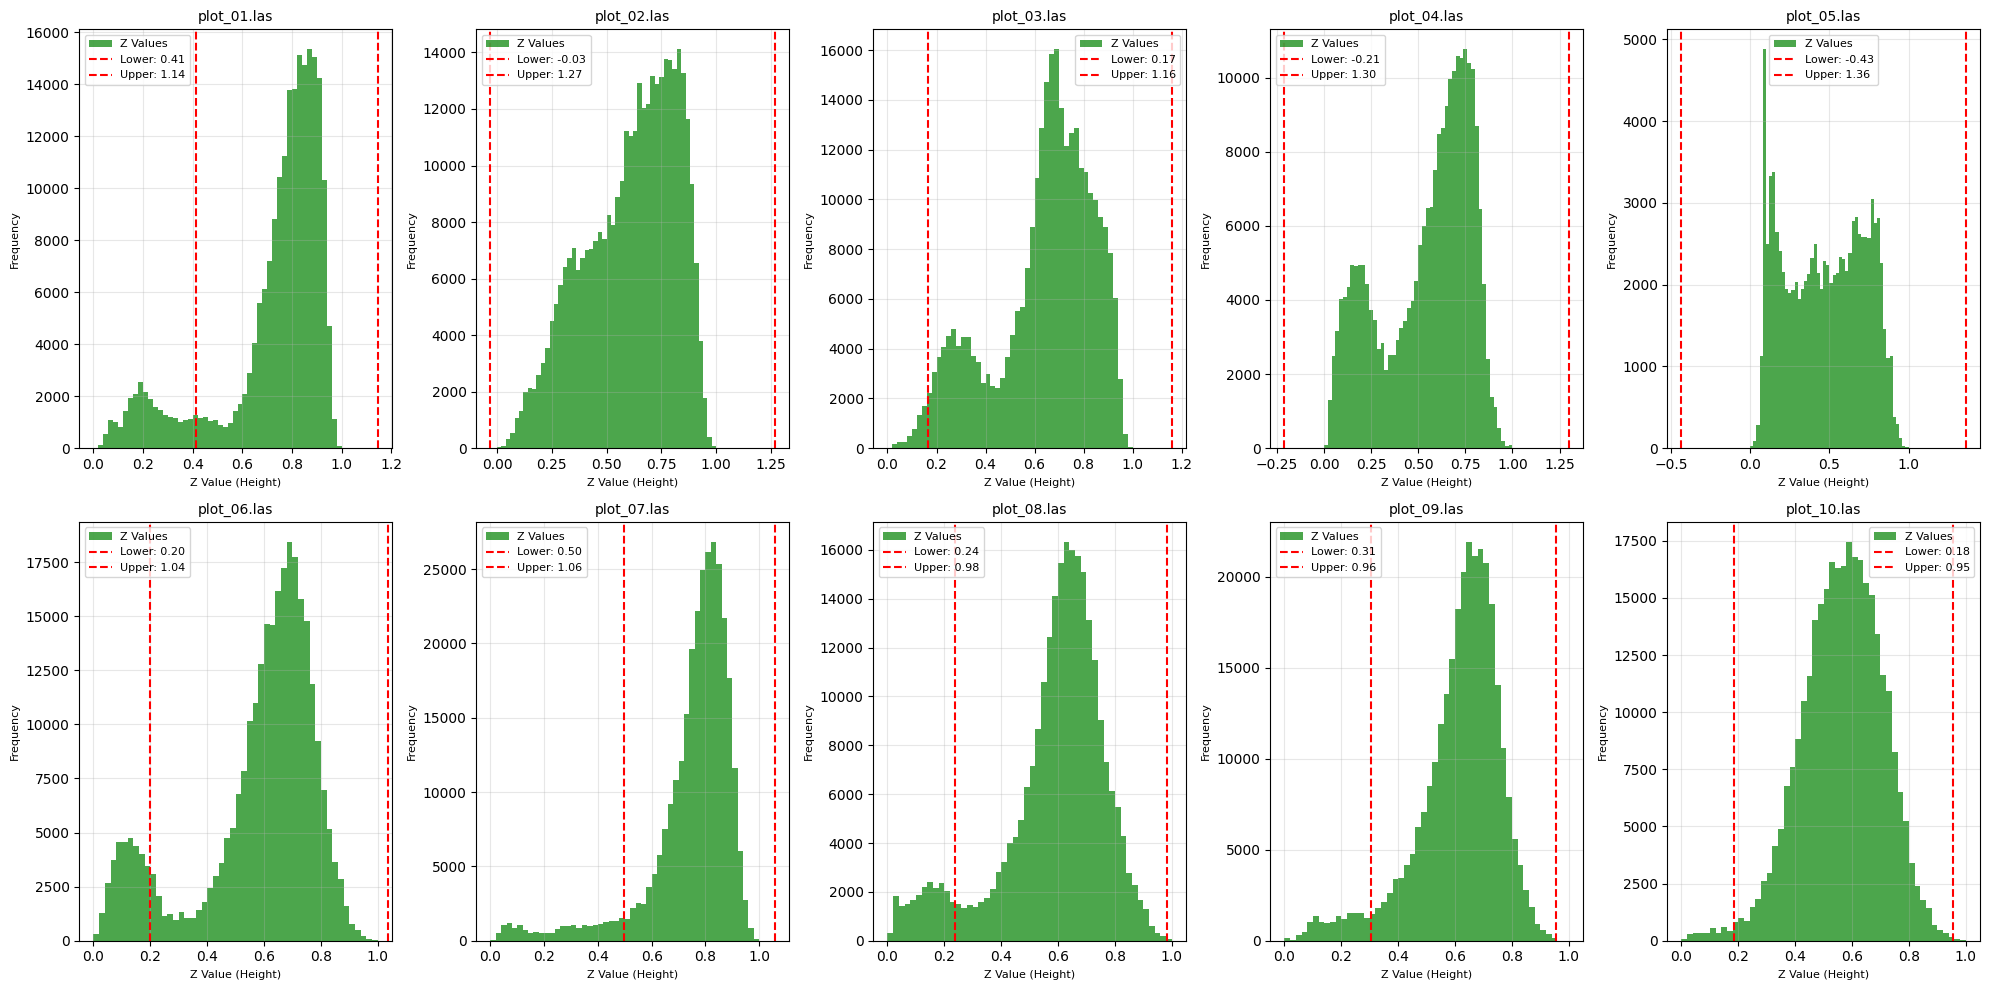

In [152]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, file_path in enumerate(plot_las_files[:10]):
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")

    # Load and filter points
    points = load_and_filter_las(file_path, filter_class=5)
    if points is None or len(points) == 0:
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue

    normalized_points = normalize_points(points)

    plot_z_distribution(normalized_points, axes[i], file_name)


plt.tight_layout()
plt.show()

In [153]:
preprocessed_data = []

for file_path in plot_las_files:

    points = load_and_filter_las(file_path, filter_class=5)

    if points is not None and len(points) > 0:
        preprocessed_points = preprocess_data(points)
        preprocessed_data.append(preprocessed_points)

    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")

File 1: 187731 preprocessed points
File 2: 350098 preprocessed points
File 3: 290624 preprocessed points
File 4: 241722 preprocessed points
File 5: 98878 preprocessed points
File 6: 255332 preprocessed points
File 7: 283645 preprocessed points
File 8: 234435 preprocessed points
File 9: 287338 preprocessed points
File 10: 307393 preprocessed points


In [154]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data,train_ratio)

In [155]:
train_data

[array([[9.69726274e-01, 6.44857869e-03, 8.34197509e-01],
        [9.61743976e-01, 6.15011712e-04, 8.27284105e-01],
        [9.95623668e-01, 7.57187949e-02, 7.69533345e-01],
        ...,
        [9.43222423e-01, 1.06876374e-01, 8.33899517e-01],
        [9.75921980e-01, 1.36577822e-01, 9.22015615e-01],
        [9.87002131e-01, 1.46110503e-01, 9.35753025e-01]]),
 array([[0.27537538, 0.3109407 , 0.56513518],
        [0.40408009, 0.25252679, 0.41585669],
        [0.40420336, 0.25090736, 0.64995853],
        ...,
        [0.46865355, 0.21644582, 0.71182617],
        [0.46989391, 0.2109207 , 0.58457456],
        [0.46781381, 0.21101596, 0.58988224]]),
 array([[0.03623423, 0.55649112, 0.23432483],
        [0.03879158, 0.55825604, 0.23488818],
        [0.03906888, 0.55023119, 0.26508366],
        ...,
        [0.22595554, 0.99248991, 0.68125739],
        [0.21987799, 0.98610128, 0.68004619],
        [0.21717428, 0.98022742, 0.66007549]]),
 array([[0.68482503, 0.01053654, 0.31594621],
        [

In [156]:
# Parameters for local maxima detection
window_size = 0.01 # Radius for neighbor search
height_threshold = 0.05  # Minimum height to consider

for i, points in enumerate(train_data):
    print(f"Processing training file {i + 1} with {len(points)} points...")
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")

Processing training file 1 with 187731 points...
Detected 8992 local maxima in training file 1.
Processing training file 2 with 350098 points...
Detected 11415 local maxima in training file 2.
Processing training file 3 with 290624 points...
Detected 9909 local maxima in training file 3.
Processing training file 4 with 241722 points...
Detected 12623 local maxima in training file 4.
Processing training file 5 with 98878 points...
Detected 8058 local maxima in training file 5.
Processing training file 6 with 255332 points...
Detected 8413 local maxima in training file 6.
Processing training file 7 with 283645 points...
Detected 6314 local maxima in training file 7.


In [157]:
# Load ground truth from GeoJSON
ground_truth_gdf = gpd.read_file("data/field_survey.geojson")
ground_truth_gdf["plot"].value_counts().sort_index()
ground_truth_gdf["geometry.x"] = ground_truth_gdf.geometry.x
ground_truth_gdf["geometry.y"] = ground_truth_gdf.geometry.y


In [158]:
print(ground_truth_gdf.head())


   plot  tree_no species    d1    d2    dbh   age  height  angle comment  \
0   1.0      1.0   Birch  47.2  46.2  46.70   NaN    26.5    0.0    None   
1   1.0      2.0   Aspen  27.9  29.1  28.50   NaN     NaN    0.0    None   
2   1.0      3.0     Fir  12.1  13.0  12.55   NaN     NaN    0.0    None   
3   1.0      4.0   Aspen  23.3  23.7  23.50  69.0    27.4    0.0    None   
4   1.0      5.0   Aspen  23.2  31.3  27.25   NaN     NaN    0.0    None   

                         geometry  geometry.x   geometry.y  
0   POINT (547075.84 6450425.243)  547075.840  6450425.243  
1  POINT (547074.299 6450419.542)  547074.299  6450419.542  
2  POINT (547077.454 6450419.994)  547077.454  6450419.994  
3   POINT (547078.211 6450419.02)  547078.211  6450419.020  
4  POINT (547074.669 6450415.573)  547074.669  6450415.573  


In [159]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape x and y columns and apply the scaler
ground_truth_gdf[['geometry.x', 'geometry.y']] = scaler.fit_transform(ground_truth_gdf[['geometry.x', 'geometry.y']])

# Print the head of the DataFrame to verify the changes
print(ground_truth_gdf.head())

   plot  tree_no species    d1    d2    dbh   age  height  angle comment  \
0   1.0      1.0   Birch  47.2  46.2  46.70   NaN    26.5    0.0    None   
1   1.0      2.0   Aspen  27.9  29.1  28.50   NaN     NaN    0.0    None   
2   1.0      3.0     Fir  12.1  13.0  12.55   NaN     NaN    0.0    None   
3   1.0      4.0   Aspen  23.3  23.7  23.50  69.0    27.4    0.0    None   
4   1.0      5.0   Aspen  23.2  31.3  27.25   NaN     NaN    0.0    None   

                         geometry  geometry.x  geometry.y  
0   POINT (547075.84 6450425.243)    0.970489    0.997714  
1  POINT (547074.299 6450419.542)    0.969518    0.993645  
2  POINT (547077.454 6450419.994)    0.971506    0.993967  
3   POINT (547078.211 6450419.02)    0.971983    0.993272  
4  POINT (547074.669 6450415.573)    0.969751    0.990811  


In [166]:
ground_truth_gdf['height'] = ground_truth_gdf['height'].fillna(0)

# Print the updated DataFrame to verify changes
print(ground_truth_gdf.head())

   plot  tree_no species    d1    d2    dbh   age  height  angle comment  \
0   1.0      1.0   Birch  47.2  46.2  46.70   NaN    26.5    0.0    None   
1   1.0      2.0   Aspen  27.9  29.1  28.50   NaN     0.0    0.0    None   
2   1.0      3.0     Fir  12.1  13.0  12.55   NaN     0.0    0.0    None   
3   1.0      4.0   Aspen  23.3  23.7  23.50  69.0    27.4    0.0    None   
4   1.0      5.0   Aspen  23.2  31.3  27.25   NaN     0.0    0.0    None   

                         geometry  geometry.x  geometry.y  
0   POINT (547075.84 6450425.243)    0.970489    0.997714  
1  POINT (547074.299 6450419.542)    0.969518    0.993645  
2  POINT (547077.454 6450419.994)    0.971506    0.993967  
3   POINT (547078.211 6450419.02)    0.971983    0.993272  
4  POINT (547074.669 6450415.573)    0.969751    0.990811  


In [167]:
from scipy.spatial import distance_matrix

def match_candidates(ground_truth, candidates, max_distance, max_height_difference):
    """
    Match detected trees with ground truth trees using spatial and height thresholds.

    Parameters:
    - ground_truth (np.ndarray): Ground truth tree locations and heights (X, Y, Z).
    - candidates (np.ndarray): Detected tree locations and heights (X, Y, Z).
    - max_distance (float): Maximum allowed distance for matching.
    - max_height_difference (float): Maximum allowed height difference for matching.

    Returns:
    - list[dict]: Match results with classes (TP, FP, FN).
    """
    if len(ground_truth) == 0 and len(candidates) == 0:
        return []

    # Compute distance matrix between ground truth and candidates
    dist_matrix = distance_matrix(ground_truth[:, :2], candidates[:, :2])

    # Find valid matches based on distance and height thresholds
    matched_gt = np.zeros(len(ground_truth), dtype=bool)
    matched_candidates = np.zeros(len(candidates), dtype=bool)
    matches = []

    for i, gt_point in enumerate(ground_truth):
        valid_candidates = np.where((dist_matrix[i] <= max_distance) & ~matched_candidates)[0]
        if len(valid_candidates) > 0:
            closest_candidate_idx = valid_candidates[np.argmin(dist_matrix[i, valid_candidates])]
            height_diff = abs(gt_point[2] - candidates[closest_candidate_idx, 2])
            if height_diff <= max_height_difference:
                matches.append({
                    "ground_truth": tuple(gt_point),
                    "candidate": tuple(candidates[closest_candidate_idx]),
                    "distance": dist_matrix[i, closest_candidate_idx],
                    "class": "TP",  # True Positive
                })
                matched_gt[i] = True
                matched_candidates[closest_candidate_idx] = True

    # Add unmatched ground truth points as False Negatives
    matches.extend({
        "ground_truth": tuple(ground_truth[i]),
        "candidate": None,
        "class": "FN",  # False Negative
    } for i in range(len(ground_truth)) if not matched_gt[i])

    # Add unmatched candidates as False Positives
    matches.extend({
        "ground_truth": None,
        "candidate": tuple(candidates[j]),
        "class": "FP",  # False Positive
    } for j in range(len(candidates)) if not matched_candidates[j])

    return matches

In [168]:
def calculate_metrics(matches):
    """
    Calculate precision, recall, and F1-score from matches.

    Parameters:
    - matches (list[dict]): Match results with "class" field.

    Returns:
    - dict: Precision, recall, and F1-score.
    """
    if not matches:
        return {"precision": 0, "recall": 0, "f1_score": 0}

    tp = sum(1 for m in matches if m["class"] == "TP")
    fp = sum(1 for m in matches if m["class"] == "FP")
    fn = sum(1 for m in matches if m["class"] == "FN")

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    return {"precision": precision, "recall": recall, "f1_score": f1_score}

In [141]:
len(local_maxima_points)

157

In [169]:
# Parameters
window_size = 0.01
height_threshold= 0.05
max_distance = 0.01  # Maximum allowed distance for matching
max_height_difference = 0.05  # Maximum allowed height difference


for plot_id, points in enumerate(train_data, start=1):
    print(f"Processing Plot {plot_id}...")

    # Detect local maxima (trees)
    detected_trees = local_maxima_filter(points, window_size, height_threshold)

    # Get ground truth for the plot
    ground_truth_trees = ground_truth_gdf[ground_truth_gdf["plot"] == plot_id]
    ground_truth_array = ground_truth_trees[["geometry.x", "geometry.y", "height"]].to_numpy()

    if len(ground_truth_array) == 0:
        print(f"No ground truth data for Plot {plot_id}. Skipping evaluation.")
        continue

    # Match detected trees with ground truth
    matches = match_candidates(ground_truth_array, detected_trees, max_distance, max_height_difference)

    # Calculate metrics
    metrics = calculate_metrics(matches)
    print(f"Plot {plot_id} - Precision: {metrics['precision']:.2f}, Recall: {metrics['recall']:.2f}, F1-Score: {metrics['f1_score']:.2f}")

Processing Plot 1...
Plot 1 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 2...
Plot 2 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 3...
Plot 3 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 4...
Plot 4 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 5...
Plot 5 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 6...
Plot 6 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00
Processing Plot 7...
Plot 7 - Precision: 0.00, Recall: 0.00, F1-Score: 0.00


In [114]:
local_maxima_points

array([[0.53693194, 0.00213682, 0.78226871],
       [0.54510688, 0.01500368, 0.64963948],
       [0.40911523, 0.1857423 , 0.67272604],
       ...,
       [0.2421518 , 0.40840022, 0.63735148],
       [0.22369679, 0.43800165, 0.512745  ],
       [0.33111125, 0.32820446, 0.68007176]])

In [175]:
import numpy as np
import scipy.spatial

ground_truth_locations = ground_truth_gdf[["geometry.x", "geometry.y"]].to_numpy()
detected_tree_locations = local_maxima_points[:, :2]

# Debug: Ensure coordinate systems and scales match
print("Ground Truth Example:", ground_truth_locations[:5])
print("Detected Trees Example:", detected_tree_locations[:5])

# Dynamic radius testing
radii = [1.0, 2.0, 3.0, 5.0, 10.0]  # Test multiple radii
best_metrics = None

for radius in radii:
    print(f"Testing with radius: {radius}")
    ground_truth_tree = scipy.spatial.KDTree(data=ground_truth_locations)
    matches = ground_truth_tree.query_ball_point(detected_tree_locations, r=radius)

    # Debug: Inspect matches
    print(f"Matches (first 5): {matches[:5]}")

    # Calculate true positives, false positives, and false negatives
    true_positive = np.array([len(match) > 0 for match in matches])
    false_positive = sum([1 for match in matches if len(match) == 0])
    false_negative = len(ground_truth_locations) - sum(true_positive)

    # Debug: Metrics counts
    print(f"True Positives: {sum(true_positive)}, False Positives: {false_positive}, False Negatives: {false_negative}")

    if sum(true_positive) > 0:
        # Calculate performance metrics
        precision = sum(true_positive) / (sum(true_positive) + false_positive)
        recall = sum(true_positive) / len(ground_truth_locations)
        f1 = 2 * (precision * recall) / (precision + recall)

        # Calculate average distance error
        matched_distances = []
        for idx, match in enumerate(matches):
            if len(match) > 0:
                detected_point = detected_tree_locations[idx]
                ground_truth_point = ground_truth_locations[match[0]]
                distance = np.linalg.norm(detected_point - ground_truth_point)
                matched_distances.append(distance)

        average_distance_error = np.mean(matched_distances) if matched_distances else None

        # Report metrics for this radius
        print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")
        if average_distance_error is not None:
            print(f"Average Distance Error: {average_distance_error:.2f} meters")
        else:
            print("No matches found to calculate distance error.")

        # Save the best metrics
        if best_metrics is None or f1 > best_metrics["f1"]:
            best_metrics = {
                "radius": radius,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "average_distance_error": average_distance_error,
            }
    else:
        print("No true positives found for this radius.")

# Report best metrics
if best_metrics:
    print("Best Metrics:")
    print(f"Radius: {best_metrics['radius']}")
    print(f"Precision: {best_metrics['precision']:.2f}")
    print(f"Recall: {best_metrics['recall']:.2f}")
    print(f"F1-Score: {best_metrics['f1']:.2f}")
    if best_metrics["average_distance_error"] is not None:
        print(f"Average Distance Error: {best_metrics['average_distance_error']:.2f} meters")
else:
    print("No suitable matches found across all radii.")



Ground Truth Example: [[0.9704889  0.99771427]
 [0.96951751 0.99364465]
 [0.9715063  0.9939673 ]
 [0.97198349 0.99327202]
 [0.96975074 0.9908114 ]]
Detected Trees Example: [[0.53693194 0.00213682]
 [0.54510688 0.01500368]
 [0.40911523 0.1857423 ]
 [0.54425605 0.06883769]
 [0.40746621 0.20192543]]
Testing with radius: 1.0
Matches (first 5): [list([420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 5